# Sweep Pulse Duration and Integration Length
The experiment plots the pulse duration and amount of the waveform to average across (integration length) versus the output current. This is used to determine the most accurate and shortest pulse duration for a 2D Coulomb diamond sweep, since when the current reaches a maximum we know the voltage has risen to its final value.\
\
Using a QRM module, this experiment was tested by connecting O1 and O2 each to a 1MOhm resistor, then the other port of these resistors were connected to the input of a preamp. The 50Ohm preamp output was then connected to I1 of Qblox.\
\
Authors: Noah Stieler, Luke Dyer

In [2]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
from qblox_instruments import Cluster

#### Connect and Configure Qblox

In [2]:
# List connected devies
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
# Make a cluster object
cluster = Cluster("cluster_mm", "192.168.137.2")

# List of all the present modules in the device
modules = [mod for mod in cluster.modules if mod.present()]

# Check which module is the QRM
for mod in modules:
	print(mod.module_type)

# Assign the module we will be using
module = modules[1]

# Set the sequencers to synchronize
module.sequencer0.sync_en(True)

# Configure scope mode
module.scope_acq_sequencer_select(0) # Set the aquisitions to happen on sequencer 0
# Set the trigger for the aquisitions to be from the Q1ASM program on sequencer 0
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")

# Configure the sequencer
module.sequencer0.thresholded_acq_rotation(0)
module.sequencer0.thresholded_acq_threshold(0)

# Map sequencers to specific outputs (first disable all sequencers connections)
module.disconnect_outputs()
module.disconnect_inputs()

# We are using the QRM so map only sequencer 0 to the outputs
module.sequencer0.connect_sequencer("io0_1")

QCM
QRM
QCM


#### Experiment Parameters

In [4]:
# Sweep Parameters
minRampUpTime = 1000
maxRampUpTime = 25000
numRampUpTimeSteps = 25

minIntegrationLength = 1000
maxIntegrationLength = 16000
numIntegrationLengthSteps = 25

rampUpTimes = np.linspace(minRampUpTime, maxRampUpTime, numRampUpTimeSteps)
integrationLengths = np.linspace(minIntegrationLength, maxIntegrationLength, numIntegrationLengthSteps)

preampSensitivity = 1e-5

#### Make JSON Sequence

In [5]:
def getSequenceDict(integrationLength, rampUpTime):
    seq_prog = ""

    while rampUpTime > 16000:
        seq_prog += f"""
        play			0,0,16000
        """
        rampUpTime -= 16000

    seq_prog += f"""
        play			0,0,{int(rampUpTime)}
        play			0,0,4
        acquire			0,0,{int(integrationLength)}
        stop									# Stop sequence
        """

    # Dictionary to hold the waveforms
    waveforms = {
        "block": {
            "data": [1.0 for i in range(0, 16000)],
            "index": 0
        },
    }

    # Acquisitions
    acquisitions = {
        "avgBins": {"num_bins": 1, "index": 0},
    }

    # Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
    sequence = {
        "waveforms": waveforms,
        "weights": {},
        "acquisitions": acquisitions,
        "program": seq_prog,
    }

    return sequence

#### Preform Sweep

In [6]:
dataSets = []

for rampUpTime in rampUpTimes:
	dataSets.append([])
	for integrationLength in integrationLengths:
		# Upload sequence.
		module.sequencer0.sequence(getSequenceDict(integrationLength, rampUpTime))

		module.sequencer0.integration_length_acq(integrationLength)
		# Arm and start both sequencers
		module.arm_sequencer(0)
		module.start_sequencer()

		# Sequencer State
		# print(module.get_sequencer_state(0))

		# Wait for the sequencer to stop with a timeout period of one minute.
		module.get_acquisition_state(0, 1)

		# Get acquisition list from instrument.
		avgAcq = module.get_acquisitions(0)["avgBins"]

		dataSets[-1].append(avgAcq["acquisition"]["bins"]["integration"]["path0"][0])

#### Process and Plot Data

In [7]:
# Integration values are multipled by -1 because preamp inverts the output voltage
# Not entirely sure, but the QBlox ADC has an input range of +-2V and it maps
# inputs as a percentage of that range. So, a 1V input to the ADC maps to 0.5V, therefore
# multiply by 2 to accurately reflect the input voltages to the ADC.
correctionFactor = -2

# Length of the integration to average over the entire integration
int_len = module.sequencer0.integration_length_acq()

for datas in dataSets: # - Luke
	for data in datas:
		# Avg the data, apply the preamp sensetivity and finally the correction factor
		data = correctionFactor*preampSensitivity*(data / int_len)

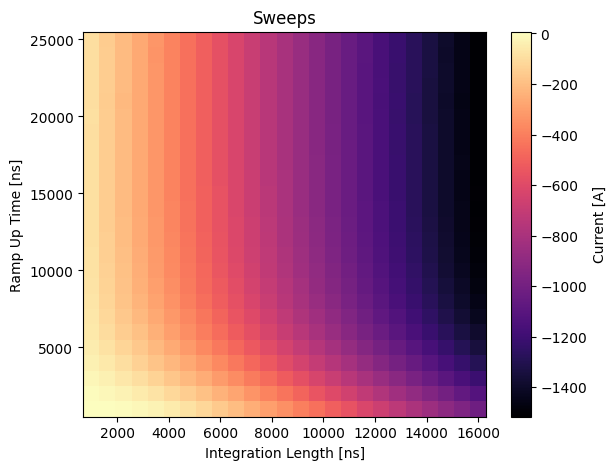

In [8]:

# Plot bins
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
heatmapImage = ax.pcolormesh(integrationLengths, rampUpTimes, dataSets, cmap="magma")
colourBar = fig.colorbar(heatmapImage)

colourBar.set_label("Current [A]")
ax.set_xlabel("Integration Length [ns]")
ax.set_ylabel("Ramp Up Time [ns]")
ax.set_title("Sweeps")
plt.show()

#### Stop the Module

In [9]:
module.stop_sequencer()
print(module.get_sequencer_state(0))

cluster.reset()
print(cluster.get_system_state())

Status: STOPPED, Flags: FORCED_STOP, ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE
Status: OKAY, Flags: NONE, Slot flags: NONE
